In [3]:
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from collections import defaultdict
from scipy import stats
from turker_eval_lib import *

In [4]:
pd.options.display.max_columns = None

### Load turker results

In [5]:
path = "../connectives_turkers_results_all.csv"
df_turkers = pd.read_csv(path)

max_batches = int((len(df_turkers) / 9) + 1) # 9 is number of workers per problem, +1 is to work with range(1,max_batches)
# Seperate same worker doing two different batches

worker_ids = []
remaining = ["tmp"]
while not len(remaining) == 0:
    remaining = []
    worker_ids = []
    for index, row in df_turkers.iterrows():
        worker = df_turkers.loc[index, "WorkerId"]
        if not worker in worker_ids:
            worker_ids.append(worker)
        else:
            df_turkers.loc[index,"WorkerId"] = str(worker) + "_SECOND"
            worker = df_turkers.loc[index, "WorkerId"]
            worker_ids.append(worker)
            remaining.append(worker)

#add num answered to df
if "num_answered" in df_turkers.columns:
    df_turkers = df_turkers.drop('num_answered', axis=1)
df_turkers.insert(column="num_answered", loc=len(df_turkers.columns), value=0)

# df.insert(column="nones", loc=len(df.columns), value=0)

prev_seen = set()

for batch in range(1,max_batches): #six batches
    answers = get_answers(get_abs_batch(df_turkers, batch))
    
    q_sets = (len(answers.columns) - 1) // 2 #minus 1 for worker ids, div by 2 b/c two questions for each 'choice'
    questions = answers.columns[1:]

    for i in range(q_sets):

        q1 = questions[2 * i]
        q2 = questions[2 * i + 1]
        
        for worker in answers["WorkerId"]:
            worker_df = df_turkers.loc[df_turkers["WorkerId"] == worker]
            if (not (worker_df[q1].values[0] == worker_df[q2].values[0])):
                df_turkers.loc[df_turkers["WorkerId"] == worker, "num_answered"] += 1

#calculate agreements
all_agreements = {}
all_agreements_scores = []
for batch in range(1, max_batches):
    all_agreements.update(agreement(df_turkers, batch))

# add agreement rate to df
df_turkers.insert(column="agreement", loc=len(df_turkers.columns), value=None)
for worker in all_agreements.keys():
    df_turkers.loc[df_turkers["WorkerId"] == str(worker), "agreement"] = (all_agreements[worker] / 25)
df_turkers['agreement'] = df_turkers['agreement'].astype(float)

drop_percent = 20

fastest = set(find_bottom(df_turkers, "WorkTimeInSeconds", "WorkerId", drop_percent))
disagreers = set(find_bottom(df_turkers, "agreement", "WorkerId", drop_percent))
indecisives = set(find_bottom(df_turkers, "num_answered", "WorkerId", drop_percent))

bottom_in_everything_set = fastest.union(indecisives).union(disagreers)

for worker in bottom_in_everything_set:
    df_turkers = df_turkers[df_turkers["WorkerId"] != worker]

In [6]:
# df_turkers.to_csv("turker_clean.csv")

In [7]:
all_questions = set()
for q in get_answers(df_turkers).columns[1:]:
    vals = q.split("_")
    item = int(vals[0].strip("Answers."))
    category = vals[2]
    all_questions.add((category, item))
len(all_questions)
print("First four:", list(all_questions)[0:4])

First four: [('temporal', 7), ('temporal', 16), ('preference', 132), ('temporal', 25)]


In [8]:
def get_consensus(category, item):
    df = get_q_answers(df_turkers, category, item)
    consensus_vals = df["Choice"].value_counts(dropna=False)
    
    freq_None = consensus_vals.get(None)
    freq_1 = consensus_vals.get(1)
    freq_2 = consensus_vals.get(2)

    if freq_None == None:
        freq_None = 0
    if freq_1 == None:
        freq_1 = 0
    if freq_2 == None:
        freq_2 = 0
    
    max = np.max([freq_None, freq_1, freq_2])
    consensus = pd.DataFrame(columns=["answer","inference","percent"])
    if max == -1:
        raise Exception("TODO: fix this if it ever happens")
    
    response_count = freq_1 + freq_2 + freq_None

    if max == freq_None:
        consensus.loc[len(consensus)] = ([None, None, freq_None / response_count])
    if max == freq_1:
        inference = df.columns[1].split("_")[6]
        consensus.loc[len(consensus)] = ([1, inference, freq_1 / response_count])
    if max == freq_2:
        inference = df.columns[2].split("_")[6]
        consensus.loc[len(consensus)] = ([2, inference, freq_2 / response_count])

    return consensus

In [9]:
get_consensus("preference", 167)

,answer,inference,percent
0,2,Wugsville has mountains.,0.571429


In [10]:
get_consensus("temporal", 164)

,answer,inference,percent
0,1,daxday occured after wugfest.,0.428571
1,2,wugfest occured after daxday.,0.428571


In [11]:
counter = 0
for category, item in all_questions:
    tmp = get_consensus(category, item)
    if len(tmp) > 1:
        # print(tmp["percent"].values[0])
        counter += 1
        # print(category, item, list(tmp["answer"]))

print(counter)
print(round(counter / len(all_questions) * 100,4), "%", "have more than one answer")

62
13.7778 % have more than one answer


### Load model results

In [12]:
#firstpass (minus gpt2)
path1 = "../outputs/babylm--babyllama-100m-2024_results.csv"
# path2 = "../outputs/gpt2_results.csv"
path3 = "../outputs/meta-llama--Llama-3.1-8B_results.csv"
path4 = "../outputs/meta-llama--Llama-3.1-8B-Instruct_results.csv"
path5 = "../outputs/meta-llama--Llama-3.2-3B_results.csv"
path6 = "../outputs/mistralai--Mistral-7B-Instruct-v0.3_results.csv"
path7 = "../outputs/mistralai--Mistral-7B-v0.3_results.csv"
path8 = "../outputs/babylm--opt-125m-strict_results.csv"

df_babyllama = pd.read_csv(path1)
# df_gpt2 = pd.read_csv(path2)
df_llama_3_8B = pd.read_csv(path3)
df_llama_3_8B_instruct = pd.read_csv(path4)
df_llama_3_2_3B_instruct = pd.read_csv(path5)
df_mistral_7B_instruct = pd.read_csv(path6)
df2_mistral_7B = pd.read_csv(path7)
df_babylm = pd.read_csv(path8)

firstpass_modeldata = [ df_llama_3_8B, df_llama_3_8B_instruct, df_llama_3_2_3B_instruct, df_mistral_7B_instruct, df2_mistral_7B, df_babyllama, df_babylm] #, df_gpt2]
firstpass_model_names =   ["llama_3_8B", "llama_3_8B_instruct", "llama_3_2_3B_instruct", "mistral_7B_instruct", "mistral_7B", "babyllama", "babylm",]#"gpt2",]

In [13]:
#gemma
path1 = "../outputs/google--gemma-2-2b_results.csv"
path2 = "../outputs/google--gemma-2-2b-it_results.csv"
path3 = "../outputs/google--gemma-2-9b_results.csv"
path4 = "../outputs/google--gemma-2-9b-it_results.csv"

df_gemma_2b = pd.read_csv(path1)
df_gemma_2b_it = pd.read_csv(path2)
df_gemma_9b = pd.read_csv(path3)
df_gemma_9b_it = pd.read_csv(path4)

gemma_modeldata = [ df_gemma_2b, df_gemma_2b_it, df_gemma_9b, df_gemma_9b_it]
gemma_model_names =  ["gemma_2b", "gemma_2b_it", "gemma_9b", "gemma_9b_it"]

In [14]:
#small models (gpt2 and pythia)
path1 = "../outputs/gpt2_results.csv"
path2 = "../outputs/gpt2-medium_results.csv"
path3 = "../outputs/gpt2-large_results.csv"
path4 = "../outputs/gpt2-xl_results.csv"
path5 = "../outputs/pythia-1.4b_results.csv"
path6 = "../outputs/pythia-14m_results.csv"
path7 = "../outputs/pythia-70m_results.csv"
path8 = "../outputs/pythia-160m_results.csv"

df_gpt2 = pd.read_csv(path1)
df_gpt2_medium = pd.read_csv(path2)
df_gpt2_large = pd.read_csv(path3)
df_gpt2_xl = pd.read_csv(path4)
df_pythia_1_4b = pd.read_csv(path5)
df_pythia_14m = pd.read_csv(path6)
df_pythia_70m = pd.read_csv(path7)
df_pythia_160m = pd.read_csv(path8)

small_modeldata = [df_gpt2, df_gpt2_medium, df_gpt2_large, df_gpt2_xl, df_pythia_14m, df_pythia_70m, df_pythia_160m, df_pythia_1_4b]
small_model_names = ["gpt2", "gpt2_medium", "gpt2_large", "gpt2_xl", "pythia_14m", "pythia_70m", "pythia_160m", "pythia_1_4b", ]

In [15]:
#OLMo
path1 = "../outputs/OLMo-1B-0724-hf_results.csv"
path2 = "../outputs/OLMo-7B-0724-hf_results.csv"
path3 = "../outputs/OLMo-7B-0724-Instruct-hf_results.csv"

OLMo_1B = pd.read_csv(path1)
OLMo_7B = pd.read_csv(path2)
OLMo_7B_Instruct = pd.read_csv(path3)

olmo_modeldata = [OLMo_1B, OLMo_7B, OLMo_7B_Instruct]
olmo_model_names = ["OLMo_1B", "OLMo_7B", "OLMo_7B_Instruct"]

In [16]:
all_modeldata = []
model_names = []

all_modeldata.extend(firstpass_modeldata)
all_modeldata.extend(gemma_modeldata)
all_modeldata.extend(small_modeldata)
all_modeldata.extend(olmo_modeldata)

model_names.extend(firstpass_model_names)
model_names.extend(gemma_model_names)
model_names.extend(small_model_names)
model_names.extend(olmo_model_names)

In [17]:
def add_category_and_items(df:pd.DataFrame):
    if not "category" in df.columns:
        df.insert(2, "category", None)
    if not "item" in df.columns:
        df.insert(2, "item", None)
    
    for index, row in df.iterrows():
        premise = row["premise"]
        category = row["inference_id_A"].split("_")[2]
        item = row["inference_id_A"].split("_")[0]
        
        df.loc[df["premise"] == premise, "category"] = category
        df.loc[df["premise"] == premise, "item"] = item
        
    return

for df in all_modeldata:
    add_category_and_items(df)

In [18]:
df_mistral_7B_instruct.head(2)
# df_babyllama.head(2)

,Unnamed: 0,premise,item,category,inference_A,inference_id_A,inference_B,inference_id_B,nonce_A,nonce_B,prompt_QA,prompt_A_YN,prompt_B_YN,rating_QA_A,rating_QA_B,rating_A_YN_Y,rating_A_YN_N,rating_B_YN_Y,rating_B_YN_N
0,0,"I find feps such as blickets, to be cute.",38,instantiation,feps are instances of blickets.,38_8_instantiation_feps_such as_blickets_feps ...,blickets are instances of feps.,38_8_instantiation_feps_such as_blickets_blick...,feps,blickets,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,-2.393658,-1.916630,-1.799585,-3.022252,-1.081381,-9.365498
1,1,"daxday happened. Hence, fepfestival happened.",125,temporal,daxday occured before fepfestival.,125_5_temporal_daxday_hence_fepfestival_daxday...,fepfestival occured before daxday.,125_5_temporal_daxday_hence_fepfestival_fepfes...,daxday,fepfestival,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,-1.473123,-1.110032,-4.052398,-2.599909,-5.521340,-1.984694


In [19]:
def add_model_choices_QA(df:pd.DataFrame):
    # How it makes it's choice:
    # P(inference A | context) > P(inference B | context) 
    #   ==> pick inference A
    # otherwise, inference B
    
    if not "QA_choice" in df.columns:
        df.insert(len(df.columns), "QA_choice", None)
    if not "QA_choice_inference" in df.columns:
        df.insert(len(df.columns), "QA_choice_inference", None)
    
    for index, row in df.iterrows():
        premise = row["premise"]

        answered_A = row["rating_QA_A"] > row["rating_QA_B"]
        if row["rating_QA_A"] == row["rating_QA_B"]:
            print("AAAAAAAAAAAAAAA")
        
        if answered_A:
            df.loc[df["premise"] == premise, "QA_choice"] = "A"
            df.loc[df["premise"] == premise, "QA_choice_inference"] = row["inference_A"]
        else:
            df.loc[df["premise"] == premise, "QA_choice"] = "B"
            df.loc[df["premise"] == premise, "QA_choice_inference"] = row["inference_B"]
    return

for df in all_modeldata:
    add_model_choices_QA(df)

In [20]:
def add_model_choices_YN(df:pd.DataFrame):
    # How it makes it's choice:
    #  P(yes|inference_A, context) > P(no|inference_A, context) ==> pick infr. A
    #  P(yes|inference_B, context) > P(no|inference_B, context) ==> pick infr. B
    # if both picked:
    #  Pick higher probability yes
    
    if not "YN_choice" in df.columns:
        df.insert(len(df.columns), "YN_choice", None)
    if not "YN_choice_inference" in df.columns:
        df.insert(len(df.columns), "YN_choice_inference", None)
    
    for index, row in df.iterrows():
        premise = row["premise"]

        answered_A_yes = (row["rating_A_YN_Y"] > row["rating_A_YN_N"])
        answered_B_yes = (row["rating_B_YN_Y"] > row["rating_B_YN_N"])

        if answered_B_yes and answered_A_yes:
            if row["rating_A_YN_Y"] > row["rating_B_YN_Y"]:
                df.loc[df["premise"] == premise, "YN_choice"] = "A"
                df.loc[df["premise"] == premise, "YN_choice_inference"] = row["inference_A"]
            else:
                df.loc[df["premise"] == premise, "YN_choice"] = "B"
                df.loc[df["premise"] == premise, "YN_choice_inference"] = row["inference_B"]
            
        elif not(answered_B_yes or answered_A_yes):
            df.loc[df["premise"] == premise, "YN_choice"] = "neither"
            df.loc[df["premise"] == premise, "YN_choice_inference"] ="neither"
            
        elif answered_A_yes:
            df.loc[df["premise"] == premise, "YN_choice"] = "A"
            df.loc[df["premise"] == premise, "YN_choice_inference"] = row["inference_A"]
        else: # answered_B_yes
            df.loc[df["premise"] == premise, "YN_choice"] = "B"
            df.loc[df["premise"] == premise, "YN_choice_inference"] = row["inference_B"]
    return

for df in all_modeldata:
    add_model_choices_YN(df)

In [21]:
def add_model_choices_YN_strict(df:pd.DataFrame):
    # How it makes it's choice:
    #  P(yes|inference_A, context) > P(no|inference_A, context) ==> pick infr. A
    #  P(yes|inference_B, context) > P(no|inference_B, context) ==> pick infr. B
    # if both picked:
    #  Pick both, only correct if humans also picked both.
    
    if not "YN_choice" in df.columns:
        df.insert(len(df.columns), "YN_choice", None)
    if not "YN_choice_inference" in df.columns:
        df.insert(len(df.columns), "YN_choice_inference", None)
    
    for index, row in df.iterrows():
        premise = row["premise"]
        
        answered_A_yes = (row["rating_A_YN_Y"] > row["rating_A_YN_N"])
        answered_B_yes = (row["rating_B_YN_Y"] > row["rating_B_YN_N"])
        
        
        if answered_B_yes and answered_A_yes:
            df.loc[df["premise"] == premise, "YN_strict_choice"] = "both"
            df.loc[df["premise"] == premise, "YN_strict_choice_inference"] ="both"
        elif not(answered_B_yes or answered_A_yes):
            df.loc[df["premise"] == premise, "YN_strict_choice"] = "neither"
            df.loc[df["premise"] == premise, "YN_strict_choice_inference"] ="neither"
        elif answered_A_yes:
            df.loc[df["premise"] == premise, "YN_strict_choice"] = "A"
            df.loc[df["premise"] == premise, "YN_strict_choice_inference"] = row["inference_A"]
        else: # answered_B_yes
            df.loc[df["premise"] == premise, "YN_strict_choice"] = "B"
            df.loc[df["premise"] == premise, "YN_strict_choice_inference"] = row["inference_B"]
    return

for df in all_modeldata:
    add_model_choices_YN_strict(df)

In [22]:
def add_model_choices_YN_ratio(df:pd.DataFrame):
    # How it makes it's choice:
    #  P(yes|inference_A, context) > P(no|inference_A, context) ==> pick infr. A
    #  P(yes|inference_B, context) > P(no|inference_B, context) ==> pick infr. B
    # if both picked:
    #  Pick both, only correct if humans also picked both.
    
    if not "YN_ratio_choice" in df.columns:
        df.insert(len(df.columns), "YN_ratio_choice", None)
    if not "YN_ratio_choice_inference" in df.columns:
        df.insert(len(df.columns), "YN_ratio_choice_inference", None)
    
    for index, row in df.iterrows():
        premise = row["premise"]
        
        A_yes = row["rating_A_YN_Y"] / (row["rating_A_YN_Y"] + row["rating_A_YN_N"])
        A_no = row["rating_A_YN_N"] / (row["rating_A_YN_Y"] + row["rating_A_YN_N"])
        B_yes = row["rating_B_YN_Y"] / (row["rating_B_YN_Y"] + row["rating_B_YN_N"])
        B_no = row["rating_B_YN_N"] / (row["rating_B_YN_Y"] + row["rating_B_YN_N"])
        
        answered_A_yes = (A_yes > A_no)
        answered_B_yes = (B_yes > B_no)
        
        if answered_B_yes and answered_A_yes:
            if answered_A_yes > answered_B_yes:
                df.loc[df["premise"] == premise, "YN_ratio_choice"] = "A"
                df.loc[df["premise"] == premise, "YN_ratio_choice_inference"] = row["inference_A"]
            else:
                df.loc[df["premise"] == premise, "YN_ratio_choice"] = "B"
                df.loc[df["premise"] == premise, "YN_ratio_choice_inference"] = row["inference_B"]
            
        elif not(answered_B_yes or answered_A_yes):
            df.loc[df["premise"] == premise, "YN_ratio_choice"] = "neither"
            df.loc[df["premise"] == premise, "YN_ratio_choice_inference"] ="neither"
            
        elif answered_A_yes:
            df.loc[df["premise"] == premise, "YN_ratio_choice"] = "A"
            df.loc[df["premise"] == premise, "YN_ratio_choice_inference"] = row["inference_A"]
        else: # answered_B_yes
            df.loc[df["premise"] == premise, "YN_ratio_choice"] = "B"
            df.loc[df["premise"] == premise, "YN_ratio_choice_inference"] = row["inference_B"]
    return

for df in all_modeldata:
    add_model_choices_YN_ratio(df)

In [23]:
def add_model_choices_YN_ratio_strict(df:pd.DataFrame):
    # How it makes it's choice:
    #  P(yes|inference_A, context) > P(no|inference_A, context) ==> pick infr. A
    #  P(yes|inference_B, context) > P(no|inference_B, context) ==> pick infr. B
    # if both picked:
    #  Pick both, only correct if humans also picked both.
    
    if not "YN_choice" in df.columns:
        df.insert(len(df.columns), "YN_choice", None)
    if not "YN_choice_inference" in df.columns:
        df.insert(len(df.columns), "YN_choice_inference", None)
    
    for index, row in df.iterrows():
        premise = row["premise"]
        
        A_yes = row["rating_A_YN_Y"] / (row["rating_A_YN_Y"] + row["rating_A_YN_N"])
        A_no = row["rating_A_YN_N"] / (row["rating_A_YN_Y"] + row["rating_A_YN_N"])
        B_yes = row["rating_B_YN_Y"] / (row["rating_B_YN_Y"] + row["rating_B_YN_N"])
        B_no = row["rating_B_YN_N"] / (row["rating_B_YN_Y"] + row["rating_B_YN_N"])
        
        answered_A_yes = (A_yes > A_no)
        answered_B_yes = (B_yes > B_no)
        
        
        if answered_B_yes and answered_A_yes:
            df.loc[df["premise"] == premise, "YN_ratio_strict_choice"] = "both"
            df.loc[df["premise"] == premise, "YN_ratio_strict_choice_inference"] ="both"
        elif not(answered_B_yes or answered_A_yes):
            df.loc[df["premise"] == premise, "YN_ratio_strict_choice"] = "neither"
            df.loc[df["premise"] == premise, "YN_ratio_strict_choice_inference"] ="neither"
        elif answered_A_yes:
            df.loc[df["premise"] == premise, "YN_ratio_strict_choice"] = "A"
            df.loc[df["premise"] == premise, "YN_ratio_strict_choice_inference"] = row["inference_A"]
        else: # answered_B_yes
            df.loc[df["premise"] == premise, "YN_ratio_strict_choice"] = "B"
            df.loc[df["premise"] == premise, "YN_ratio_strict_choice_inference"] = row["inference_B"]
    return

for df in all_modeldata:
    add_model_choices_YN_ratio_strict(df)

In [24]:
for df in all_modeldata:
    if not "agree_w_human_QA" in df.columns:
        df.insert(len(df.columns), "agree_w_human_QA", 0)
    if not "agree_w_human_YN_strict" in df.columns:
        df.insert(len(df.columns), "agree_w_human_YN_strict", 0)
    if not "agree_w_human_YN" in df.columns:
        df.insert(len(df.columns), "agree_w_human_YN", 0)
    if not "agree_w_human_YN_ratio" in df.columns:
        df.insert(len(df.columns), "agree_w_human_YN_ratio", 0)
    if not "agree_w_human_YN_ratio_strict" in df.columns:
        df.insert(len(df.columns), "agree_w_human_YN_ratio_strict", 0)

In [25]:
for model in all_modeldata:
    for category, item in all_questions:
        consensus = get_consensus(category, item)
        
        human_answers = consensus["inference"]
        human_percents = consensus["percent"] 

        model_answer_QA = model.loc[((model["item"] == str(item)) & (model["category"] == category)), "QA_choice_inference"].values
        model_answer_YN = model.loc[((model["item"] == str(item)) & (model["category"] == category)), "YN_choice_inference"].values
        model_answer_YN_strict = model.loc[((model["item"] == str(item)) & (model["category"] == category)), "YN_strict_choice_inference"].values
        model_answer_YN_ratio_strict = model.loc[((model["item"] == str(item)) & (model["category"] == category)), "YN_ratio_strict_choice_inference"].values
        model_answer_YN_ratio = model.loc[((model["item"] == str(item)) & (model["category"] == category)), "YN_ratio_choice_inference"].values
        
        # did the humans answer with both inferences? 
        # (the second portion of the 'and' is "if the humans answered two values were acceptable, 'No Choice' was not one of them")
        human_answer_both = (len(human_answers.values) > 1) and ((len(human_answers.values) == 2) or (not math.nan in human_answers.values))
         # These conditions are true if: 
            #   A) the model picked a value that the humans picked, or 
            #   B) the humans picked both and the model picked both as well
        
        if (model_answer_QA in human_answers.values) or (model_answer_QA == "both" and human_answer_both):
            model.loc[((model["item"] == str(item)) & (model["category"] == category)), "agree_w_human_QA"] = 1
        
        if (model_answer_YN in human_answers.values) or (model_answer_YN == "both" and human_answer_both):
            model.loc[((model["item"] == str(item)) & (model["category"] == category)), "agree_w_human_YN"] = 1
            
        if (model_answer_YN_strict in human_answers.values) or (model_answer_YN_strict == "both" and human_answer_both):
            model.loc[((model["item"] == str(item)) & (model["category"] == category)), "agree_w_human_YN_strict"] = 1

        if (model_answer_YN_ratio_strict in human_answers.values) or (model_answer_YN_ratio_strict == "both" and human_answer_both):
            model.loc[((model["item"] == str(item)) & (model["category"] == category)), "agree_w_human_YN_ratio_strict"] = 1
        
        if (model_answer_YN_ratio in human_answers.values) or (model_answer_YN_ratio == "both" and human_answer_both):
            model.loc[((model["item"] == str(item)) & (model["category"] == category)), "agree_w_human_YN_ratio"] = 1
        
        
        model.loc[((model["item"] == str(item)) & (model["category"] == category)), "human_percent"] = np.min(list(human_percents.values))
            

In [26]:
df_mistral_7B_instruct.head(3)
# df_babyllama.head(3)

,Unnamed: 0,premise,item,category,inference_A,inference_id_A,inference_B,inference_id_B,nonce_A,nonce_B,prompt_QA,prompt_A_YN,prompt_B_YN,rating_QA_A,rating_QA_B,rating_A_YN_Y,rating_A_YN_N,rating_B_YN_Y,rating_B_YN_N,QA_choice,QA_choice_inference,YN_choice,YN_choice_inference,YN_strict_choice,YN_strict_choice_inference,YN_ratio_choice,YN_ratio_choice_inference,YN_ratio_strict_choice,YN_ratio_strict_choice_inference,agree_w_human_QA,agree_w_human_YN_strict,agree_w_human_YN,agree_w_human_YN_ratio,agree_w_human_YN_ratio_strict,human_percent
0,0,"I find feps such as blickets, to be cute.",38,instantiation,feps are instances of blickets.,38_8_instantiation_feps_such as_blickets_feps ...,blickets are instances of feps.,38_8_instantiation_feps_such as_blickets_blick...,feps,blickets,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,-2.393658,-1.916630,-1.799585,-3.022252,-1.081381,-9.365498,B,blickets are instances of feps.,B,blickets are instances of feps.,both,both,neither,neither,neither,neither,0,0,0,0,0,0.750000
1,1,"daxday happened. Hence, fepfestival happened.",125,temporal,daxday occured before fepfestival.,125_5_temporal_daxday_hence_fepfestival_daxday...,fepfestival occured before daxday.,125_5_temporal_daxday_hence_fepfestival_fepfes...,daxday,fepfestival,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,-1.473123,-1.110032,-4.052398,-2.599909,-5.521340,-1.984694,B,fepfestival occured before daxday.,neither,neither,neither,neither,B,fepfestival occured before daxday.,both,both,1,0,0,1,0,0.583333
2,2,gekxtravaganza happened even before wugfest.,91,temporal,wugfest occured before gekxtravaganza.,91_1_temporal_wugfest_even before_gekxtravagan...,gekxtravaganza occured before wugfest.,91_1_temporal_wugfest_even before_gekxtravagan...,wugfest,gekxtravaganza,Given the following statement:\ngekxtravaganza...,Given the following statement:\ngekxtravaganza...,Given the following statement:\ngekxtravaganza...,-0.750385,-0.920060,-6.807633,-1.895965,-1.343098,-7.477803,A,wugfest occured before gekxtravaganza.,B,gekxtravaganza occured before wugfest.,B,gekxtravaganza occured before wugfest.,A,wugfest occured before gekxtravaganza.,A,wugfest occured before gekxtravaganza.,1,0,0,1,1,0.583333


In [27]:
def print_model_accuracies(all_modeldata, model_names, category="all", minpercent=0.0):    
    for model, name in zip(all_modeldata, model_names):
        model_alt = None
        if not category == "all":
            model_alt = model.loc[(model["category"] == category) & (model["human_percent"] >= minpercent)]
        else:
            model_alt = model.loc[model["human_percent"] >= (minpercent)]
       
        print(len(model_alt.loc[model_alt["agree_w_human"] == 1]), "\t", round(len(model_alt.loc[model_alt["agree_w_human"] == 1]) / len(model_alt) * 100, 2), "%\t", name, )

In [28]:
def model_accuracies(all_modeldata, model_names, category="all", minpercent=0.0, prompt_style="QA"):
    accs = pd.DataFrame(columns=["models","percent","absolute_num", "total"])
    for model, name in zip(all_modeldata, model_names):
        model_alt = None
        if not category == "all":
            model_alt = model.loc[(model["category"] == category) & (model["human_percent"] >= minpercent)]
        else:
            model_alt = model.loc[model["human_percent"] >= (minpercent)]
        
        agree_w_human = "agree_w_human_" + prompt_style
        
        percent = len(model_alt.loc[model_alt[agree_w_human] == 1]) / len(model_alt)
        absolute_num = len(model_alt.loc[model_alt[agree_w_human] == 1])
        total = len(model_alt)
        
        # print(len(model_alt.loc[model_alt["agree_w_human"] == 1]), "\t", round(len(model_alt.loc[model_alt["agree_w_human"] == 1]) / len(model_alt) * 100, 2), "%\t", name, )
        accs.loc[len(accs)] = [name, str(round(percent * 100, 1)) + "%", absolute_num, total]
    
    return accs


model_accuracies(all_modeldata, model_names, minpercent=0, prompt_style="YN")

,models,percent,absolute_num,total
0,llama_3_8B,55.3%,249,450
1,llama_3_8B_instruct,31.3%,141,450
2,llama_3_2_3B_instruct,56.2%,253,450
3,mistral_7B_instruct,53.3%,240,450
4,mistral_7B,63.8%,287,450
5,babyllama,0.0%,0,450
6,babylm,30.0%,135,450
7,gemma_2b,56.2%,253,450
8,gemma_2b_it,64.2%,289,450
9,gemma_9b,61.6%,277,450


In [29]:
def plot_accs_basic(accs, title="Model Accuracy", color=None):
    y = accs["absolute_num"]
    x = accs["models"]
    bar_labels = accs["percent"]

    

    max = accs["total"][0]
    fig = plt.figure(figsize=(15,5))
    plt.axhline(y=max,color="w")
    
    
    bar = plt.bar(x, y, color=color)

    for b, label in zip(bar, bar_labels):
        height = b.get_height()
        plt.text(b.get_x() + b.get_width() / 2.0, height, label, ha='center', va='bottom', fontsize=9, fontweight="roman")

    plt.xticks(rotation=-30, ha="left", va="top", rotation_mode="anchor")
    range = np.append(np.arange(0, max, 50).tolist(), max)
    plt.yticks(range)

    plt.title(title)
    plt.xlabel("Model Name")
    plt.ylabel("Number Correct")

    plt.show()

In [30]:
def plot_accs(accs, title="Model Accuracy", color=None, ylabel="Number Correct"):
    y = accs["absolute_num"]
    x = accs["models"]
    bar_labels = accs["percent"]

    max = accs["total"][0]
    fig, ax = plt.subplots() 
    fig.set_figheight(5)
    fig.set_figwidth(15)
    ax.axhline(y=max,color="w")
    
    positions = np.arange(len(x) * 1.0)
    positions[ 7:] += 0.75
    positions[11:] += 0.75
    positions[15:] += 0.75
    positions[19:] += 0.75
    
    bar = ax.bar(positions, y, color=color)
    
    ax.set_xticks(positions)
    ax.set_xticklabels(x) 
    for b, label in zip(bar, bar_labels):
        height = b.get_height()
        plt.text(b.get_x() + b.get_width() / 2.0, height, label, ha='center', va='bottom', fontsize=9, fontweight="roman")

    plt.xticks(rotation=-30, ha="left", va="top", rotation_mode="anchor")
    range = np.append(np.arange(0, max, 50).tolist(), max)
    plt.yticks(range)

    plt.title(title)
    plt.xlabel("Model Name")
    plt.ylabel(ylabel)

    plt.show()

In [33]:
minpercent = 0.0
prompt_style = "QA"

### Data Graphs

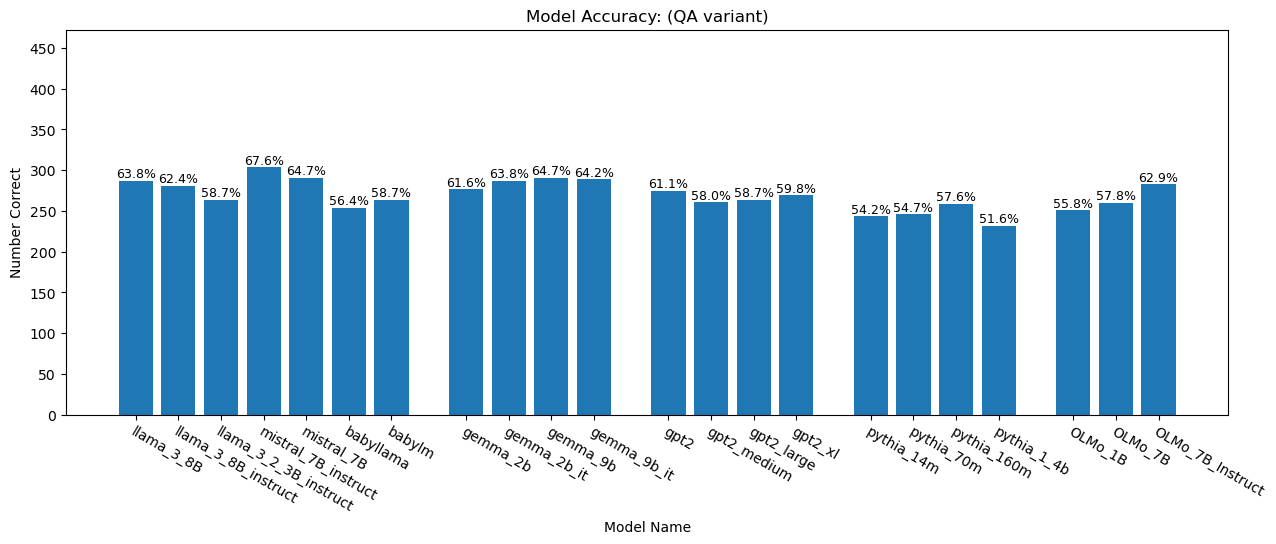

In [34]:
title="Model Accuracy: " + "(" + prompt_style + " variant" + ")"

accs = model_accuracies(all_modeldata, model_names, prompt_style=prompt_style, minpercent=minpercent)
plot_accs(accs, title=title)

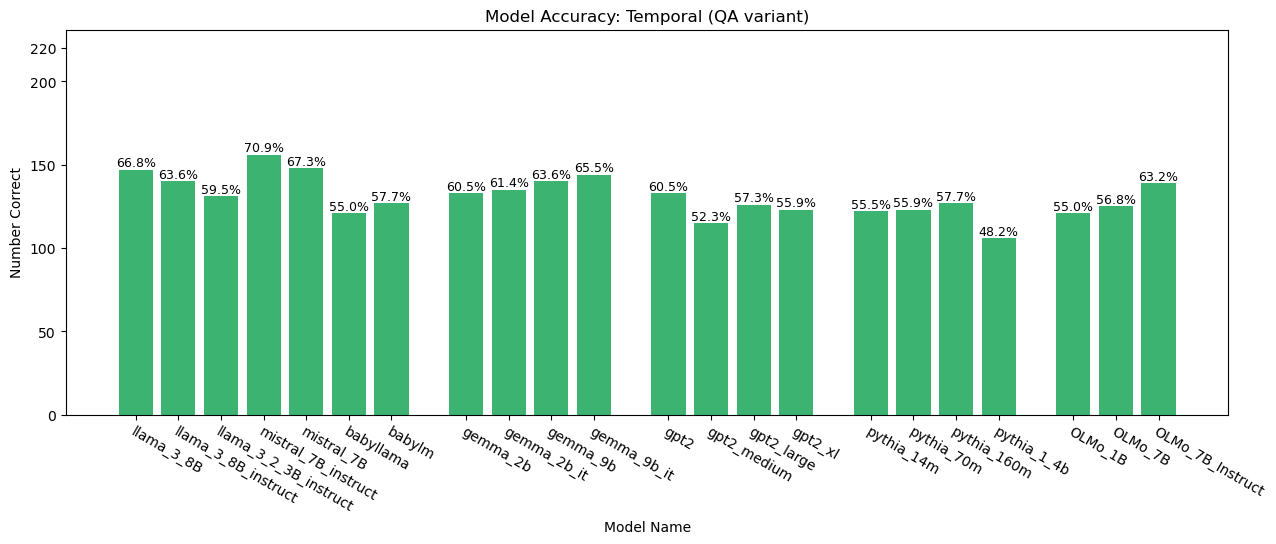

In [35]:
title="Model Accuracy: Temporal " + "(" + prompt_style + " variant" + ")"
accs_temp = model_accuracies(all_modeldata, model_names, category="temporal", prompt_style=prompt_style, minpercent=minpercent)
plot_accs(accs_temp, title=title, color="mediumseagreen")

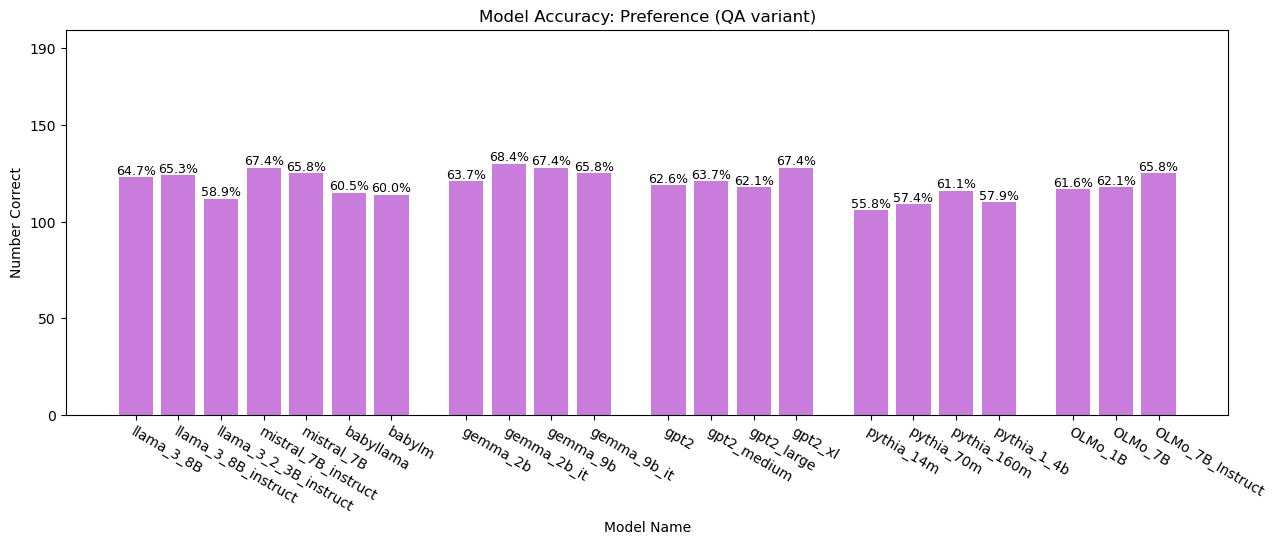

In [36]:
title="Model Accuracy: Preference " + "(" + prompt_style + " variant" + ")"
accs_pref = model_accuracies(all_modeldata, model_names, category="preference", prompt_style=prompt_style, minpercent=minpercent)
plot_accs(accs_pref, title=title, color="#CA7CDC")

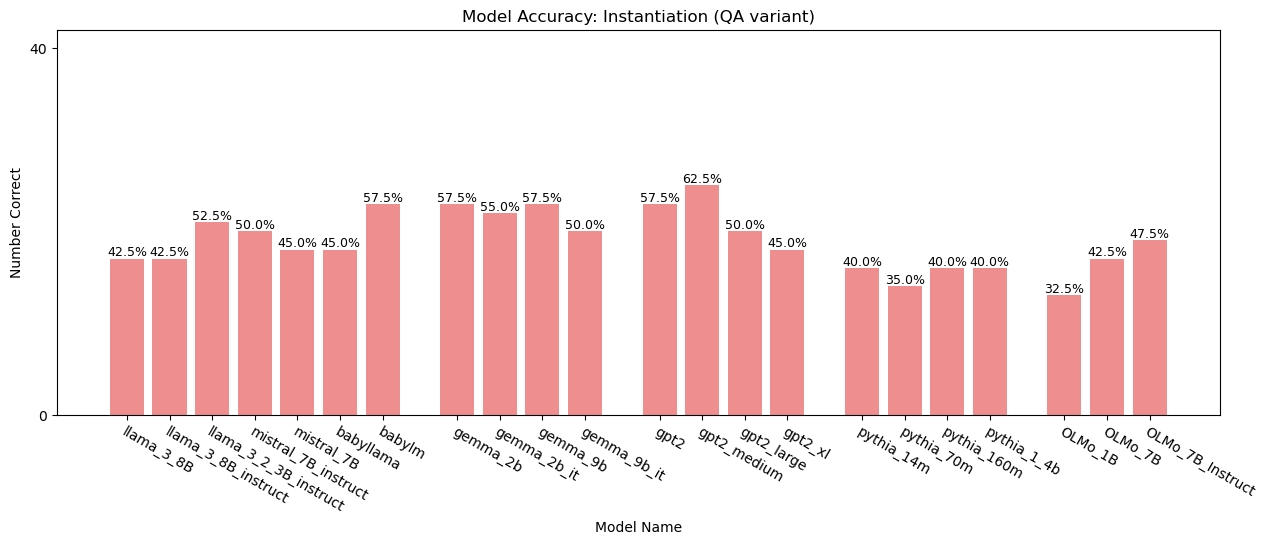

In [37]:
title="Model Accuracy: Instantiation " + "(" + prompt_style + " variant" + ")"
accs_inst = model_accuracies(all_modeldata, model_names, category="instantiation", prompt_style=prompt_style, minpercent=minpercent)
plot_accs(accs_inst, title=title, color="#EF8E8E")

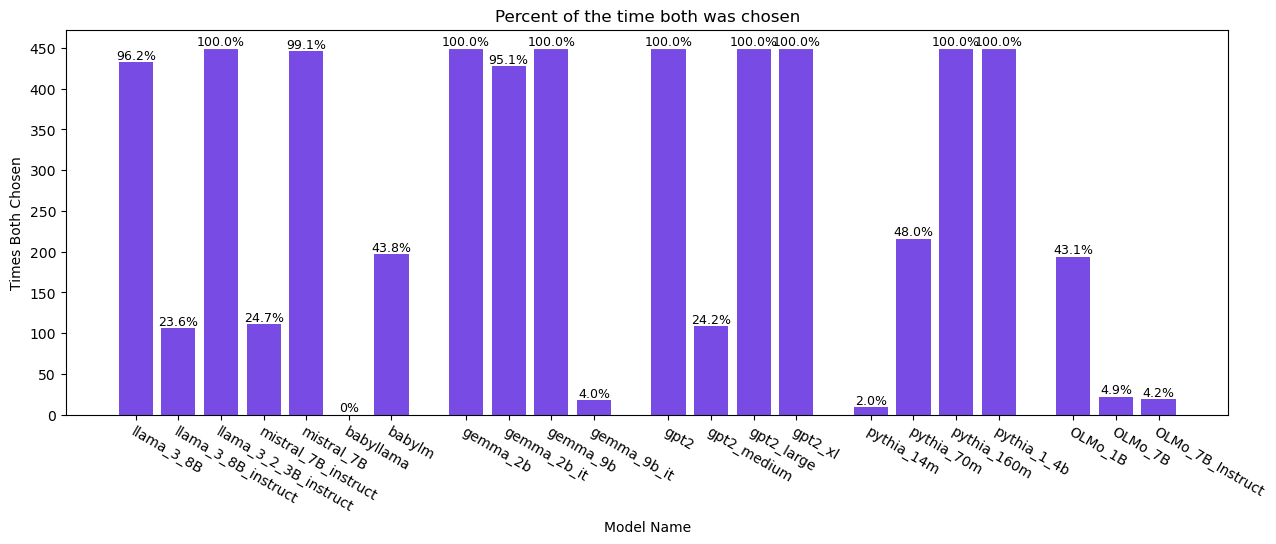

In [38]:
both_percents = pd.DataFrame(columns=["models","percent","absolute_num", "total"])

for model, name in zip(all_modeldata, model_names):
    values = model["YN_strict_choice"].value_counts()
    absolute_num = 0
    percent = 0
    if "both" in values:
        absolute_num = values["both"]
        percent = values["both"] / len(model)
    total = len(model)
    
    both_percents.loc[len(both_percents)] = [name, str(round(percent * 100, 1)) + "%", absolute_num, total]
plot_accs(both_percents, "Percent of the time both was chosen", ylabel="Times Both Chosen", color="#784CE4")

In [141]:
df_differences = pd.DataFrame(columns=None, index=range(len(df_babyllama)))
for model, name in zip(all_modeldata, model_names):
    df_differences["rating_QA_A_" + name] = model["rating_QA_A"]
    df_differences["rating_QA_B_" + name] = model["rating_QA_B"]

    df_differences[name + "_diff"] = (np.array(model["rating_QA_A"]) - np.array(model["rating_QA_B"]))
    print(np.mean(df_differences[name + "_diff"]), "\t", name)
# df_differences.head()

0.1023169215520223 	 llama_3_8B
0.21111643857426113 	 llama_3_8B_instruct
0.09875409947501289 	 llama_3_2_3B_instruct
0.058071419563558366 	 mistral_7B_instruct
0.06610010279549493 	 mistral_7B
0.0716424534055922 	 babyllama
0.320964269373152 	 babylm
0.24607569747500949 	 gemma_2b
0.48388080332014294 	 gemma_2b_it
0.15951664037174648 	 gemma_9b
0.22526192320717706 	 gemma_9b_it
0.2147017028596666 	 gpt2
0.23001768456565008 	 gpt2_medium
0.2098441645834181 	 gpt2_large
0.22432220379511517 	 gpt2_xl
0.5690733046001858 	 pythia_14m
0.8304012449582417 	 pythia_70m
0.4408836613761054 	 pythia_160m
0.16228097836176555 	 pythia_1_4b
0.2366533241007063 	 OLMo_1B
0.0899251749780443 	 OLMo_7B
0.1550038303931554 	 OLMo_7B_Instruct


In [142]:
# Normal display, for if  new models are added
# plt.rcdefaults()

# pltwidth = 4
# pltheight= 6
# fig, axes = plt.subplots(pltwidth, pltheight, sharex=True, sharey=True)
# fig.set_figheight(10)
# fig.set_figwidth(20)
# # plt.subplots_adjust(wspace=.75, hspace=.25)
# plt.subplots_adjust(hspace=.25)


# pltx = 0
# plty = 0

# for model, name in zip(all_modeldata, model_names):
#     y = np.sort(df_differences[name + "_diff"])
    
#     axes[pltx, plty].axvline(x=0, c="black", linestyle="dotted", linewidth=1)
#     axes[pltx, plty].axhline(y=80, c="white", linestyle="dotted", linewidth=1)
    
#     axes[pltx, plty].hist(y,bins=75,range=(-3,3))
#     axes[pltx, plty].set_title(name)
    
    
#     pltx += 1
#     if pltx >= pltwidth:
#         pltx = 0
#         plty += 1
        
# plt.show()

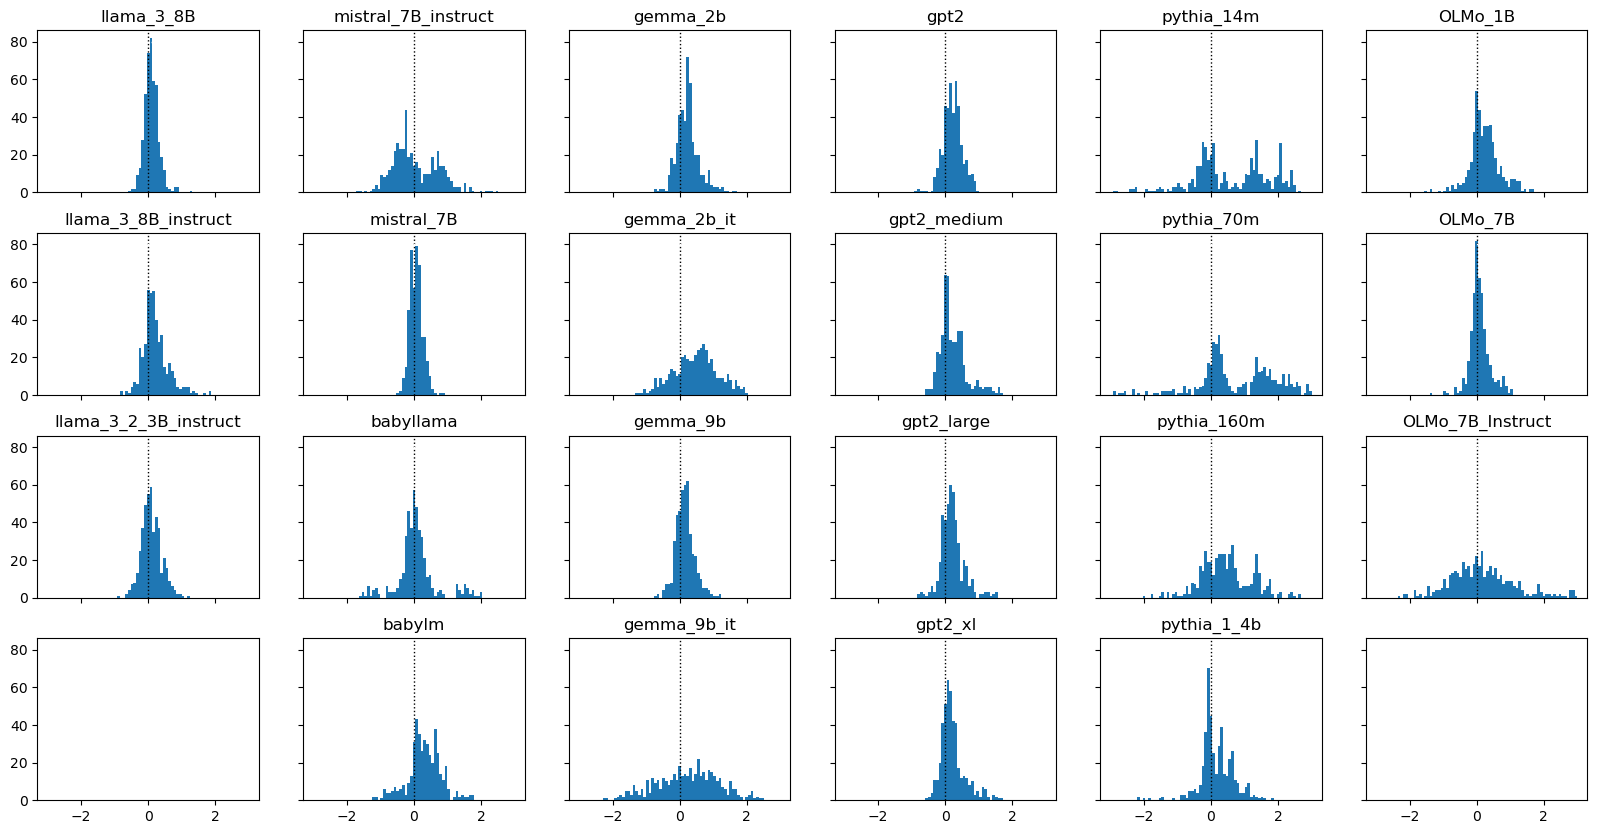

In [143]:
plt.rcdefaults()

pltwidth = 4
pltheight= 6
fig, axes = plt.subplots(pltwidth, pltheight, sharex=True, sharey=True)
fig.set_figheight(10)
fig.set_figwidth(20)
# plt.subplots_adjust(wspace=.75, hspace=.25)
plt.subplots_adjust(hspace=.25)


pltx = 0
plty = 0

for model, name in zip(all_modeldata, model_names):
    if (plty == 0 and pltx == 3):

        pltx += 1
        if pltx >= pltwidth:
            pltx = 0
            plty += 1
    
    y = np.sort(df_differences[name + "_diff"])
    
    axes[pltx, plty].axvline(x=0, c="black", linestyle="dotted", linewidth=1)
    axes[pltx, plty].axhline(y=80, c="white", linestyle="dotted", linewidth=1)
    
    axes[pltx, plty].hist(y,bins=75,range=(-3,3))
    axes[pltx, plty].set_title(name)
    
    
    pltx += 1
    if pltx >= pltwidth:
        pltx = 0
        plty += 1
        
plt.show()

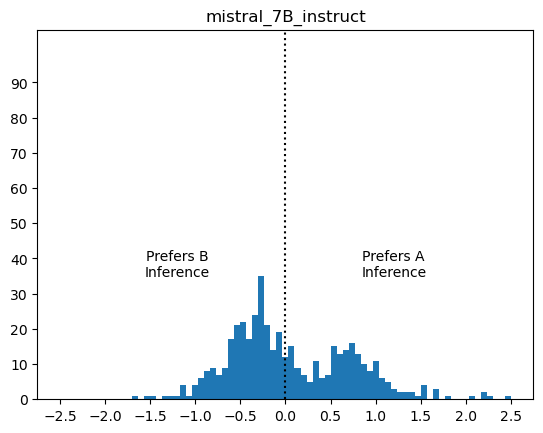

In [144]:
name = "mistral_7B_instruct"

y = np.sort(df_differences[name + "_diff"])


plt.title(name)

plt.axvline(0, color="black", linestyle="dotted")
plt.text(x=-1.2, y=35, s="Prefers B\nInference",ha="center")
plt.text(x= 1.2, y=35, s="Prefers A\nInference",ha="center")

plt.xticks(np.arange(-2.5, 2.51, .5))
plt.yticks(np.arange(0, 100, 10))

plt.axhline(100, color="w") # artificially ensure all graphs have the same height, for comparison

plt.hist(y,bins=75,range=(-2.5,2.5))
plt.show()

In [145]:
print(np.max(df_differences[name + "_diff"]))
print(np.min(df_differences[name + "_diff"]))


2.4436510801315308
-1.6752784252166748


In [146]:
df_babyllama.head(3)

,Unnamed: 0,premise,item,category,inference_A,inference_id_A,inference_B,inference_id_B,nonce_A,nonce_B,prompt_QA,prompt_A_YN,prompt_B_YN,rating_QA_A,rating_QA_B,rating_A_YN_Y,rating_A_YN_N,rating_B_YN_Y,rating_B_YN_N,QA_choice,QA_choice_inference,YN_choice,YN_choice_inference,YN_strict_choice,YN_strict_choice_inference,agree_w_human_QA,agree_w_human_YN_strict,agree_w_human_YN,human_percent,YN_ratio_strict_choice,YN_ratio_strict_choice_inference,agree_w_human_YN_ratio_strict,YN_ratio_choice,YN_ratio_choice_inference,agree_w_human_YN_ratio
0,0,"I find feps such as blickets, to be cute.",38,instantiation,feps are instances of blickets.,38_8_instantiation_feps_such as_blickets_feps ...,blickets are instances of feps.,38_8_instantiation_feps_such as_blickets_blick...,feps,blickets,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,-4.426517,-4.262149,-13.161870,-11.657465,-13.082719,-11.538742,B,blickets are instances of feps.,neither,neither,both,both,0,0,0,0.750000,both,both,0,B,blickets are instances of feps.,0
1,1,"daxday happened. Hence, fepfestival happened.",125,temporal,daxday occured before fepfestival.,125_5_temporal_daxday_hence_fepfestival_daxday...,fepfestival occured before daxday.,125_5_temporal_daxday_hence_fepfestival_fepfes...,daxday,fepfestival,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,-4.672937,-4.776929,-13.202126,-11.610996,-13.191441,-11.604681,A,daxday occured before fepfestival.,neither,neither,both,both,0,0,0,0.583333,both,both,0,B,fepfestival occured before daxday.,1
2,2,gekxtravaganza happened even before wugfest.,91,temporal,wugfest occured before gekxtravaganza.,91_1_temporal_wugfest_even before_gekxtravagan...,gekxtravaganza occured before wugfest.,91_1_temporal_wugfest_even before_gekxtravagan...,wugfest,gekxtravaganza,Given the following statement:\ngekxtravaganza...,Given the following statement:\ngekxtravaganza...,Given the following statement:\ngekxtravaganza...,-4.137755,-3.499108,-12.699673,-10.978760,-12.711307,-10.921936,B,gekxtravaganza occured before wugfest.,neither,neither,both,both,0,0,0,0.583333,both,both,0,B,gekxtravaganza occured before wugfest.,0


### output turker data

In [ ]:
# # generate clean turker dataset by bootstrapping model info haha

# columns = ["premise","category","item","inference_A", "inference_id_A", "inference_B", "inference_id_B", "nonce_A",
#            "nonce_B", "answer_1_inference","answer_2_inference","answer_3_inference","answer_percent", "answers_list", "workers_list"]
# df_turker_byquestion = pd.DataFrame(columns=columns)

# df_turker_byquestion = df_turker_byquestion.astype({"workers_list":object, "answers_list":object})
# # df_turker_byquestion.astype("workers_list", object)

# # add category, item
# df_turker_byquestion["category"] = df_babyllama["category"].copy()
# df_turker_byquestion["item"] = df_babyllama["item"].copy()

# # add infrences + premise
# df_turker_byquestion["premise"] = df_babyllama["premise"].copy()
# df_turker_byquestion["inference_A"] = df_babyllama["inference_A"].copy()
# df_turker_byquestion["inference_B"] = df_babyllama["inference_B"].copy()
# df_turker_byquestion["inference_id_A"] = df_babyllama["inference_id_A"].copy()
# df_turker_byquestion["inference_id_B"] = df_babyllama["inference_id_B"].copy()

# #add nonces
# df_turker_byquestion["nonce_A"] = df_babyllama["nonce_A"].copy()
# df_turker_byquestion["nonce_B"] = df_babyllama["nonce_B"].copy()

# #set default values for answers
# df_turker_byquestion.fillna("No other picked", inplace=True)

# for category, item in all_questions:
#     consensus = get_consensus(category, item)
#     for index, row in consensus.iterrows():
#         answer_num = "answer_" + str(index + 1) + "_inference"
#         answer = row["inference"]

#         df_turker_byquestion.loc[(df_turker_byquestion["category"] == category) & (df_turker_byquestion["item"] == str(item)), answer_num] = answer
        
#     df_turker_byquestion.loc[(df_turker_byquestion["category"] == category) & (df_turker_byquestion["item"] == str(item)), "answer_percent"] = consensus["percent"].values[0]
#     q_consensus = get_q_consensus(df_turkers, category, item)

#     df_turker_byquestion.loc[(df_turker_byquestion["category"] == category) & (df_turker_byquestion["item"] == str(item)), "answers_list"] = str((list(q_consensus["Choice"])))
#     df_turker_byquestion.loc[(df_turker_byquestion["category"] == category) & (df_turker_byquestion["item"] == str(item)), "workers_list"] = str((list(q_consensus["WorkerId"])))


In [167]:
ids = df_turker_byquestion["inference_id_A"]
connectives = []
for id in ids:
    connectives.append((id.split("_")[2],id.split("_")[4]))
    # connectives.append(id.split("_")[4])

# connectives = set(connectives)
# connectives = [c for s, c in set(connectives) if s == "preference"]
connectives = [c for s, c in (connectives) if s == "temporal"]
print(connectives)
print(len(connectives))

['hence', 'even before', 'subsequently', 'even though', 'thereafter', 'earlier', 'then', 'as a result', 'previously', 'then', 'consequently', 'after', 'consequently', 'as a result', 'before', 'hence', 'hence', 'even though', 'once', 'even after', 'later', 'earlier', 'even before', 'earlier', 'consequently', 'once', 'subsequently', 'earlier', 'after', 'since', 'finally', 'consequently', 'afterwards', 'even after', 'before', 'even though', 'because', 'as soon as', 'therefore', 'after', 'later', 'even though', 'as a result', 'subsequently', 'even though', 'finally', 'even after', 'next', 'before', 'next', 'even after', 'even though', 'earlier', 'so', 'consequently', 'earlier', 'therefore', 'as a result', 'next', 'once', 'as soon as', 'even before', 'previously', 'next', 'afterwards', 'after', 'next', 'before', 'thereafter', 'as soon as', 'previously', 'thereafter', 'thereafter', 'afterwards', 'finally', 'before', 'so', 'later', 'since', 'even after', 'because', 'before', 'after', 'because

In [150]:
# df_turker_byquestion.head(2)
# df_turker_byquestion.to_csv("turker_response_by_question.csv")